In [1]:
# importing libraries
import pandas as pd
import numpy as np

# Scaling modules
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read in data
df = pd.read_csv('titanic.csv')

**Introduction**

This notebook contains an EDA on the Titanic dataset, aiming to use summary statistics and visual plots in order to identify relationships between variables such as class, 
sex, and age. 

In [3]:
# Display the first five rows
five = df.head(5)
print(five)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
info = df.info()
print(info)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [5]:
description = df.describe()
print(description)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


**Initial Observations**

By running .head() and .info(), it is shown that the dataset has 12 columns and 891 rows representing the passengers onboard the titanic. Below are some of the key variables described in the dataset.
* **Survival** - the column titled 'survived' uses binary coding to denote whether each passenger survived the sinking of the ship
* **Passenger Details** - the columns 'sex' and 'age' use string and float datatypes respectively to represent the physical attributes of each passenger
* **Trip Details** - the columns 'pclass' (ticket class), 'sibsp' (number of siblings/spouses aboard), and 'parch' (number of parents/children aboard) tell us about how the passenger travelled and who with
* **Identifiers** - the columns 'passengerID', 'name', 'ticket' and 'cabin' give us ways to identify each passenger using a unique code/name

**Missing Data Values**

Most of the columns do not have any missing data, however 'age' is missing 177 entries, 'cabin' is missing 687 entries, and 'embarked' is missing 2 entries. This could be because records were lost or simply not collected efficiently.

Since the 'cabin' column is missing 77% of it's data, estimating in order to fill in the missing values would make the data inaccurate. However, since the 'age' column is only missing 20% of entries, these missing values can be estimated using the median age of similar passengers.


In [6]:
# dropping the 'cabin' column
df = df.drop('Cabin', axis=1)

In [7]:
# calculate median age for each group of a specific class and sex
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

Now that the dataset has been cleaned, the data can be explored in order to find out which factors determined who survived.

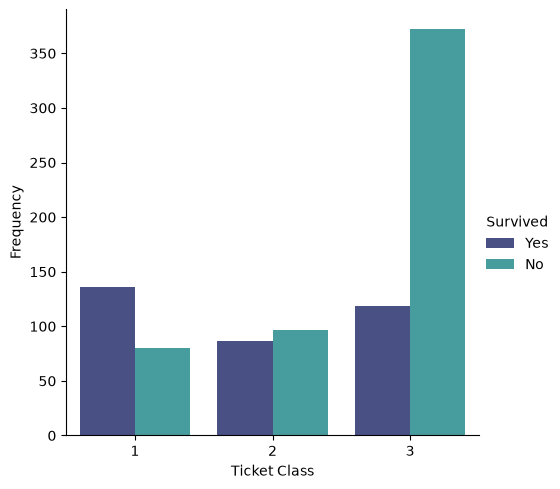

In [8]:
# survival based on ticket class

df['Survived'] = df['Survived'].map({0: 'No', 1: 'Yes'})
fg = sns.catplot(data=df, kind='count', x='Pclass', hue='Survived', palette='mako')
fg.set_axis_labels("Ticket Class", "Frequency")

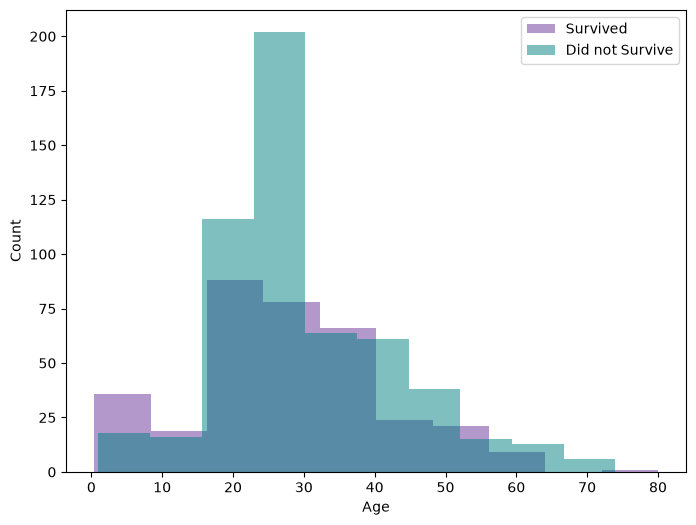

In [9]:
# survival based on age

plt.figure(figsize=(8,6))

plt.hist(df[df['Survived'] == 'Yes']['Age'], alpha=0.5, label='Survived', color='rebeccapurple')
plt.hist(df[df['Survived'] == 'No']['Age'], alpha=0.5, label='Did not Survive', color='teal')

plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()

plt.show()

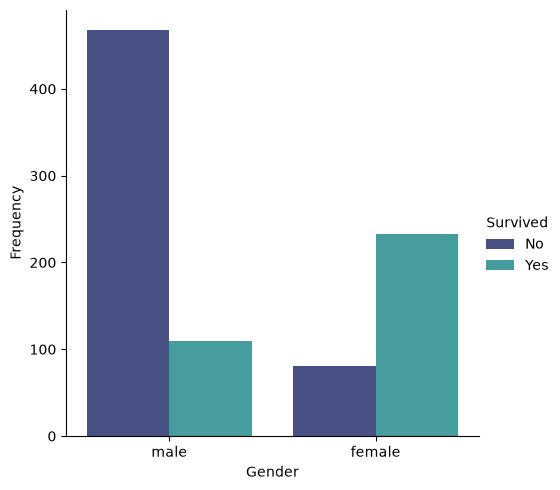

In [10]:
# survival based on gender

fg = sns.catplot(data=df, kind='count', x='Sex', hue='Survived', palette='mako')
fg.set_axis_labels("Gender", "Frequency")

**Factors in determining whether a person was likely to survive**

Using seaborn and matplotlib.pyplot, we can visually observe the impact that each passenger's class, age and gender had on their chances of survival. The findings are as follows:

* **Class** - Passengers with a first class ticket were more likely to survive than to not, though the difference wasn't huge, and passengers with a second class ticket were marginally more likely to not survive. However, passengers with a third class ticket had a much lower chance of survival, despite them being the largest percentage of ticket holders.

* **Age** - Although the two histograms follow a similar trend, suggesting that age wasn't a main factor for survival likelihood, children between the ages of 0 and 10 were more likely to survive compared to adults. In comparison, young adults between the ages of 20 and 30, again the largest percentage of ticket holders, were much more likely not to survive.

* **Gender** - Females were much more likely to survive than males, despite majority of passengers being male.


Overall, whilst these various factors all helped in determining survival, gender stands out as being the most important one. This is likely because women were given priority for boarding the lifeboats over men. 

**Lifeboat Preferences**

In the Titanic movie, the upper-class passengers were given preference on lifeboats. This does show in the data in the sense that first class passengers were more likely to survive, however a significant number still died. This may be due to the system of prioritising women over men, and the chaos of the sinking ship.

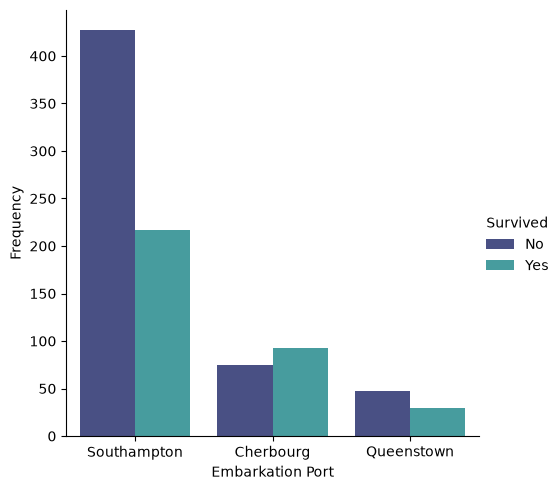

In [11]:
# survival based on embarkation port

df['Embarked'] = df['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})
fg = sns.catplot(data=df, kind='count', x='Embarked', hue='Survived', palette='mako')
fg.set_axis_labels("Embarkation Port", "Frequency")

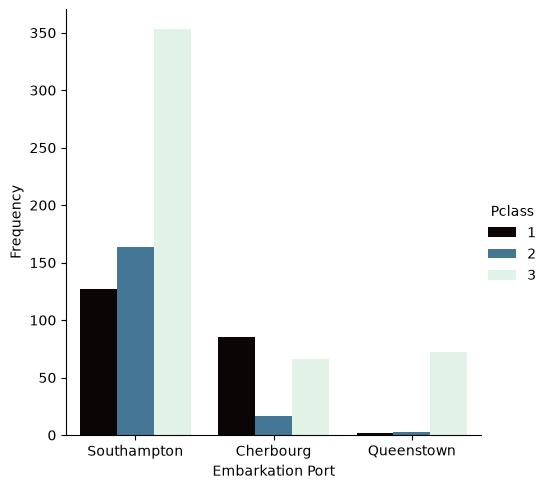

In [12]:
# ticket class based on embarkation port

fg = sns.catplot(data=df, kind='count', x='Embarked', hue='Pclass', palette='mako')
fg.set_axis_labels("Embarkation Port", "Frequency")

**Survival based on Embarkation Port**

It is shown that those who embarked from Southampton or Queenstown had a much lower chance of survival than those who embarked from Cherbourg. This is likely due to the fact that a much higher percentage of the Southampton/Queenstown passengers were third class, whereas Cherbourg had a higher percentage of first class passengers. 

**Conclusion**

In conclusion, the most important factor in determining whether a person survived the sinking of the Titanic was found to be gender, although age and ticket class also played significant roles. This is because of the 'women and children first' policy that staff enacted when boarding the lifeboats. Survival rates also differ depending on the embarkation port, however this is due to the distribution of ticket classes across ports.